In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp

from scipy.stats import zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 
from matplotlib.colors import LinearSegmentedColormap

# Define paths
mcds_path = '../../hazel/gene_mcds/gene'
rna_path = '../../hazel/count_Arab13_with_TEs.csv'
meta_path = '../../hazel/merged_cluster_assignments.csv'
gene_list_path = 'hazel_list.txt'

In [2]:
import pandas as pd
import re

gff_path = '/gale/raidix/rdx-7/jwalker/Kay_Qu/c1038_genes_overlapping_c2952_dmw_chunks.gff'

# 1. Read the GFF (Skipping comment lines starting with '#')
# GFFs are tab-separated and have 9 standard columns
gff_cols = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
df_gff = pd.read_csv(gff_path, sep='\t', comment='#', header=None, names=gff_cols)

# 2. Filter for 'gene' features only (Column 3)
genes_only = df_gff[df_gff['type'] == 'gene'].copy()

# 3. Extract the ID from the 'attributes' column
# Usually looks like: "ID=gene:AT1G01010;Name=..." or "ID=AT1G01010"
def extract_id(attr_string):
    # This regex looks for 'ID=' followed by characters until a semicolon or end of string
    match = re.search(r'ID=([^;]+)', attr_string)
    if match:
        gene_id = match.group(1)
        # Clean up common prefixes like 'gene:' if they exist
        return gene_id.replace('gene:', '')
    return None

# Apply the extraction
new_gene_list = genes_only['attributes'].apply(extract_id).dropna().unique().tolist()

# 4. Update your pipeline variable
hazel_genes = pd.Index(new_gene_list)

print(f"✅ Loaded {len(hazel_genes)} unique Gene IDs from the GFF file.")
print(f"Sample IDs: {new_gene_list[:5]}")

✅ Loaded 1038 unique Gene IDs from the GFF file.
Sample IDs: ['AT1G01300', 'AT1G01770', 'AT1G01780', 'AT1G01830', 'AT1G01950']


In [3]:
hazel_genes

Index(['AT1G01300', 'AT1G01770', 'AT1G01780', 'AT1G01830', 'AT1G01950',
       'AT1G02110', 'AT1G02500', 'AT1G03040', 'AT1G03140', 'AT1G03290',
       ...
       'AT5G63020', 'AT5G63550', 'AT5G64740', 'AT5G65280', 'AT5G66050',
       'AT5G66520', 'AT5G66600', 'AT5G67340', 'AT5G67385', 'AT5G67440'],
      dtype='object', length=1038)

In [5]:
# Load core datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")


Loaded RNA shape: (6071, 64507)
Loaded Meta shape: (5908, 1)


In [6]:
# Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# Normalize to CPM and Log1p
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6
rna_log1p = np.log1p(rna_cpm)

# Define Stage Merging Map
broad_cluster_mapping = {
    3: 'Mesophyll', 0: 'Mesophyll', 7: 'Mesophyll', 1: 'Mesophyll', 10: 'Mesophyll',
    5: 'Epidermis', 4: 'Epidermis', 6: 'Epidermis', 13: 'Epidermis', 8: 'Epidermis',
    14: 'Guard cell', 2: 'Vasculature', 11: 'PPP', 9: 'Phloem', 
    16: 'Myrosinase', 12: 'S phase', 15: 'G2M phase'
}

# Support both string and float keys to match metadata formatting safely
broad_cluster_mapping.update({str(k): v for k, v in broad_cluster_mapping.items()})
broad_cluster_mapping.update({float(k): v for k, v in broad_cluster_mapping.items() if isinstance(k, int)})

# Assign broad clusters and filter valid cells
meta['broad_cluster'] = meta['merged_cluster'].map(broad_cluster_mapping)
valid_cells = meta.loc[common_cells][meta.loc[common_cells, 'broad_cluster'].notna()].index

# Aggregate RNA by broad cluster
rna_log1p['cluster'] = meta.loc[valid_cells, 'broad_cluster']
cluster_rna_matrix = rna_log1p.groupby('cluster').mean().T

print(f"Processed RNA matrix shape: {cluster_rna_matrix.shape}")

Processed RNA matrix shape: (64507, 9)


In [7]:
cluster_rna_matrix

cluster,Epidermis,G2M phase,Guard cell,Mesophyll,Myrosinase,PPP,Phloem,S phase,Vasculature
AT1G01010,0.037457,0.123274,0.016309,0.075670,0.103218,0.000000,0.020117,0.178207,0.048096
AT1G01020,0.743411,0.481391,0.221479,0.982423,0.903148,0.203666,0.584201,0.682061,0.576624
AT1G01030,0.154466,0.370302,0.057338,0.247133,0.032590,0.138163,0.165419,0.323830,0.143114
AT1G01040,0.915504,0.920084,0.631241,1.146338,1.413787,1.777067,1.577694,0.619029,1.098356
AT1G01046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
ATMG01370,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01375,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01380,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01390,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
# Extract counts
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

# Align with valid metadata cells
valid_meth_cells = mCGN_mc.index.intersection(valid_cells)
mCGN_mc = mCGN_mc.loc[valid_meth_cells]
mCGN_cov = mCGN_cov.loc[valid_meth_cells]

# Assign broad cluster mappings
mCGN_mc['cluster'] = meta.loc[valid_meth_cells, 'broad_cluster']
mCGN_cov['cluster'] = meta.loc[valid_meth_cells, 'broad_cluster']

# Aggregate by broad cluster
cluster_c = mCGN_mc.groupby('cluster').sum().T
cluster_m = mCGN_cov.groupby('cluster').sum().T

# --- 1. Fit Global Offsets (deltas) ---
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# --- 2. Calculate Expected Methylation ---
gene_c = cluster_c.sum(axis=1)
gene_m = cluster_m.sum(axis=1)

# # Mask for coverage
# valid_genes_mask = gene_m >= 50 
# cluster_c = cluster_c[valid_genes_mask]
# cluster_m = cluster_m[valid_genes_mask]
# gene_c = gene_c[valid_genes_mask]
# gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# --- 3. Extract Residuals ---
obs_p = cluster_c / cluster_m.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

adj_meth_matrix = obs_p - p0_df

# Basic fraction filter: Must hit 10% methylation in at least one cluster
highly_meth_genes = obs_p[obs_p.apply(lambda x: (x >= 0.1).any(), axis=1)].index
filtered_meth_df = adj_meth_matrix.loc[highly_meth_genes]

print(f"Logit-adjusted Methylation matrix shape: {filtered_meth_df.shape}")

Logit-adjusted Methylation matrix shape: (13703, 9)


In [11]:
filtered_meth_df

cluster,Epidermis,G2M phase,Guard cell,Mesophyll,Myrosinase,PPP,Phloem,S phase,Vasculature
gene,,,,,,,,,
AT1G03987,-0.000175,0.110977,-0.014732,-0.003930,-0.011746,-0.013390,0.019183,0.087555,-0.001610
AT1G01040,-0.015856,0.011052,0.060093,0.001921,0.020256,-0.014109,-0.029424,-0.013113,0.040854
AT1G01046,0.014642,0.157904,0.279442,-0.018887,-0.001032,0.068830,-0.140338,0.071834,0.075406
AT1G01050,-0.009256,0.077060,-0.014700,-0.000428,-0.009799,0.022093,0.045463,0.013978,0.006563
AT1G01060,0.002265,0.000287,0.038314,-0.004443,0.013724,0.030159,0.014071,0.006169,0.008565
...,...,...,...,...,...,...,...,...,...
ATMG01410,0.011203,-0.311277,-0.128146,0.051445,0.013147,0.005410,-0.249865,-0.104440,-0.125312
ATCG00890,-0.019480,-0.021711,-0.022799,0.003770,-0.018208,0.179263,-0.017244,-0.019285,-0.020931
ATCG00960,-0.075979,-0.084127,-0.088060,0.422993,-0.071288,-0.080585,-0.067708,-0.075264,-0.081289


In [12]:
# 1. Intersect across modalities AND restrict to Hazel's list
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index).intersection(hazel_genes)

final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]
final_weights_df = cluster_m.loc[common_genes]

# 2. Independent Filtering: Keep genes with >= 0.1 log1p CPM in at least one cluster
rna_expressed_mask = final_rna_df.max(axis=1) >= 0.1
robust_common_genes = final_rna_df[rna_expressed_mask].index

final_rna_df = final_rna_df.loc[robust_common_genes]
final_meth_df = final_meth_df.loc[robust_common_genes]
final_weights_df = final_weights_df.loc[robust_common_genes]

print(f"Genes remaining for WLS after all filters: {len(robust_common_genes)}")

# 3. Run Weighted Least Squares (WLS)
correlations = []
p_values = []
valid_genes = []

for gene in robust_common_genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    weight_vals = final_weights_df.loc[gene].values
    
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue
        
    rna_z = zscore(rna_vals)
    meth_z = zscore(meth_vals)
    X = sm.add_constant(meth_z)
    
    try:
        wls_model = sm.WLS(endog=rna_z, exog=X, weights=weight_vals).fit()
        valid_genes.append(gene)
        correlations.append(wls_model.params[1])
        p_values.append(wls_model.pvalues[1])
    except Exception:
        continue

# 4. Compile and Correct (FDR)
stats_df = pd.DataFrame({
    'gene': valid_genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

if len(stats_df) > 0:
    stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]
    significant_genes = stats_df[stats_df['fdr'] < 0.05]
    top_300_genes = significant_genes.sort_values('rho').head(300).index
    
    print(f"\nFound {len(significant_genes)} statistically significant genes (FDR < 0.05).")
    print(f"Top 10 candidates from Hazel's list:")
    display(stats_df.loc[top_300_genes].head(10))
else:
    print("WARNING: stats_df is empty!")

Genes remaining for WLS after all filters: 624

Found 112 statistically significant genes (FDR < 0.05).
Top 10 candidates from Hazel's list:


,rho,p_value,fdr
gene,,,
AT1G62975,-2.293677,0.006986,0.042735
AT1G23480,-2.219861,0.008027,0.045536
AT4G30400,-2.021921,0.000690,0.009305
AT2G13360,-2.020881,0.001720,0.016773
AT3G21670,-1.970972,0.002871,0.024214
AT1G71140,-1.948702,0.001856,0.017095
AT4G20830,-1.905714,0.000856,0.010897
AT5G04870,-1.768537,0.001804,0.017095
AT1G70890,-1.740014,0.001690,0.016773


In [13]:
common_genes

Index(['AT1G01770', 'AT1G01950', 'AT1G02110', 'AT1G02500', 'AT1G03290',
       'AT1G03300', 'AT1G04030', 'AT1G04800', 'AT1G05490', 'AT1G07380',
       ...
       'AT5G62060', 'AT5G63010', 'AT5G63020', 'AT5G63550', 'AT5G64740',
       'AT5G66050', 'AT5G66520', 'AT5G66600', 'AT5G67340', 'AT5G67385'],
      dtype='object', length=852)

In [15]:
robust_common_genes

Index(['AT1G01770', 'AT1G01950', 'AT1G02110', 'AT1G02500', 'AT1G03290',
       'AT1G04030', 'AT1G04800', 'AT1G07380', 'AT1G07650', 'AT1G07990',
       ...
       'AT5G60210', 'AT5G61070', 'AT5G63010', 'AT5G63020', 'AT5G63550',
       'AT5G64740', 'AT5G66050', 'AT5G66600', 'AT5G67340', 'AT5G67385'],
      dtype='object', length=624)

In [16]:
final_rna_df

cluster,Epidermis,G2M phase,Guard cell,Mesophyll,Myrosinase,PPP,Phloem,S phase,Vasculature
AT1G01770,0.658872,0.626431,0.075163,1.216600,1.295166,0.970202,1.190956,0.855918,0.829762
AT1G01950,0.538726,0.426843,0.256087,0.304944,0.126807,0.562674,0.197745,0.230887,0.190002
AT1G02110,0.321972,0.178909,0.059187,0.153824,0.088846,0.059198,0.068746,0.181226,0.162088
AT1G02500,0.476907,0.802503,0.307141,0.446721,0.749348,0.544252,1.427847,0.379256,0.672742
AT1G03290,0.593116,0.412379,0.611702,0.463652,0.649476,0.437582,0.282976,0.142153,0.356706
...,...,...,...,...,...,...,...,...,...
AT5G64740,2.213015,2.348472,0.820615,2.371149,2.183846,1.726005,1.333682,1.266155,1.587669
AT5G66050,0.998026,0.585239,0.151162,0.851948,1.656656,0.527061,0.518624,0.360754,0.920741
AT5G66600,0.143485,0.144251,0.000000,0.108478,0.000000,0.000000,0.025441,0.090152,0.107783
AT5G67340,0.218303,0.000000,0.000000,0.035462,0.000000,0.078697,0.110522,0.009885,0.081130


Comparison: Raw Scope (852 genes) vs Filtered Scope (624 genes)


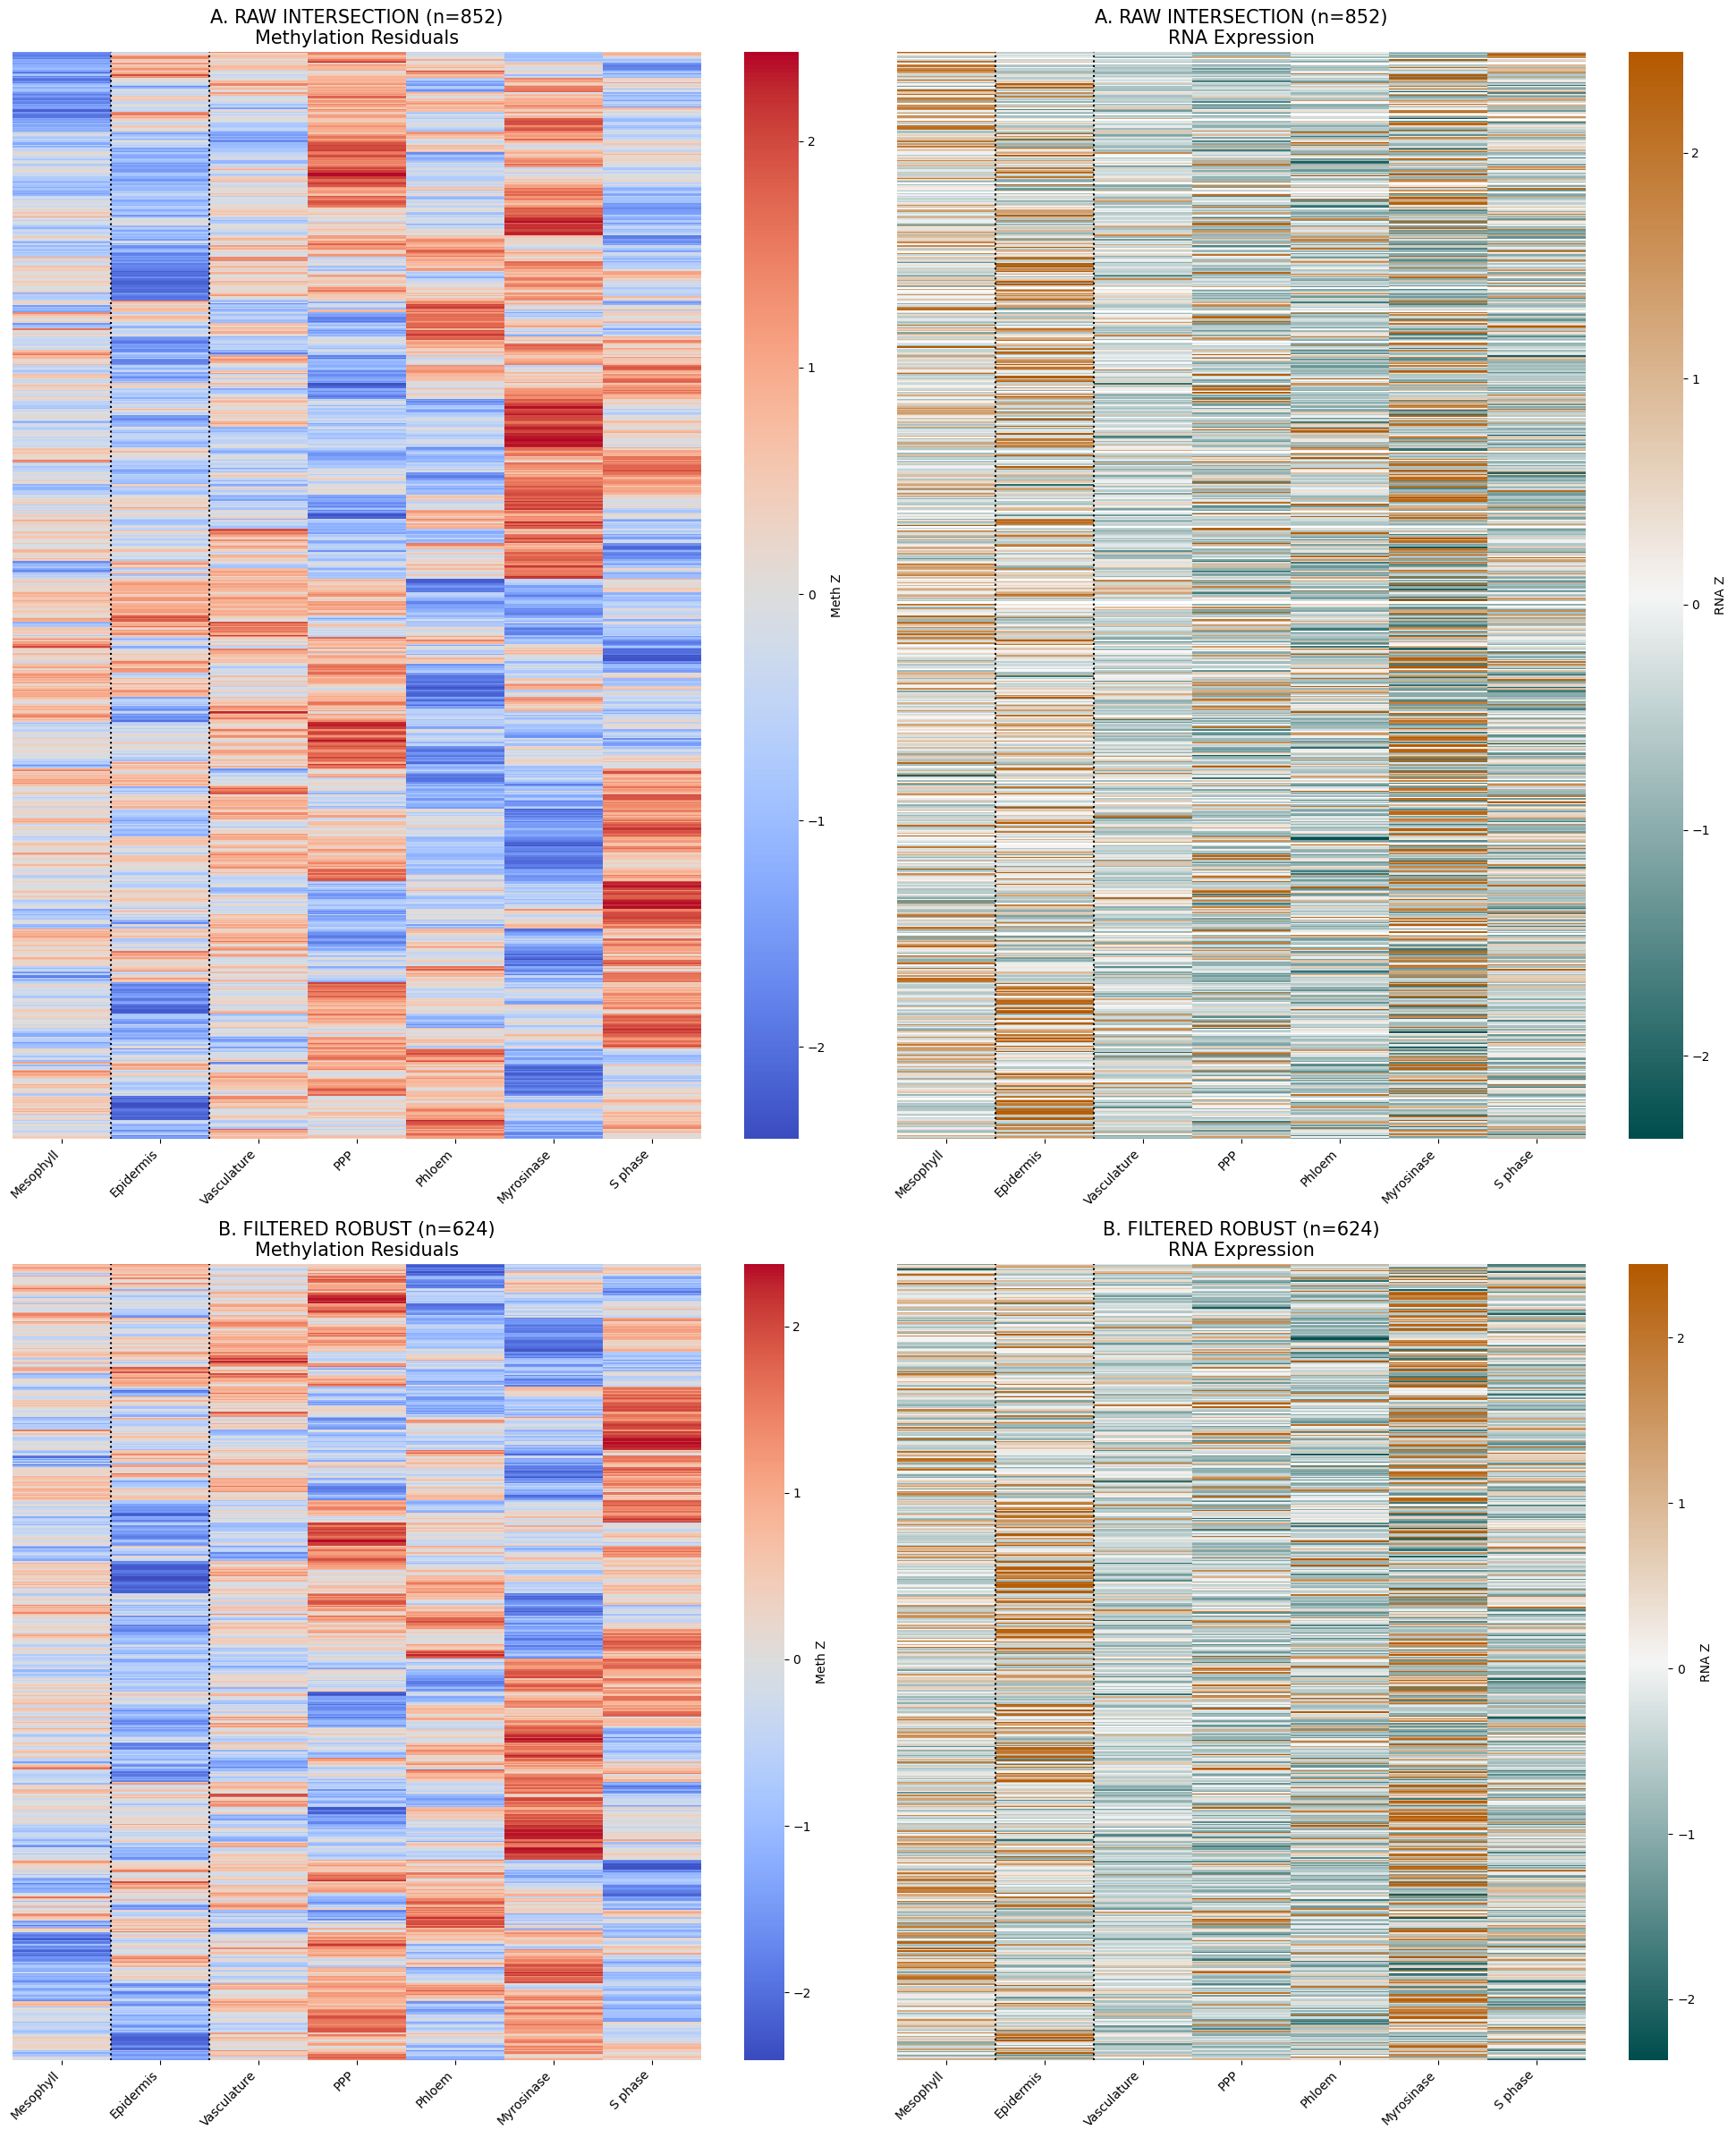

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
from matplotlib.colors import LinearSegmentedColormap

cluster_order = [
    'Mesophyll', 'Epidermis', 'Guard cell', 'Vasculature', 
    'PPP', 'Phloem', 'Myrosinase', 'S phase', 'G2M phase'
]

# 1. Define the two scopes
# Scope A: Everything that intersected
raw_scope = common_genes 
# Scope B: Only those that passed the 0.1 CPM filter
filtered_scope = robust_common_genes

print(f"Comparison: Raw Scope ({len(raw_scope)} genes) vs Filtered Scope ({len(filtered_scope)} genes)")

# 2. Helper function for Z-scoring and Clustering
def get_clustered_data(rna_df, meth_df, genes, cluster_cols):
    # Subset and Z-score
    z_meth = meth_df.loc[genes, cluster_cols].apply(zscore, axis=1).clip(-2.5, 2.5)
    z_rna = rna_df.loc[genes, cluster_cols].apply(zscore, axis=1).clip(-2.5, 2.5)
    
    # Hierarchical Clustering based on Methylation pattern
    if len(genes) > 1:
        linkage = hc.linkage(sp.distance.pdist(z_meth.values), method='ward')
        order = hc.leaves_list(linkage)
        return z_meth.iloc[order], z_rna.iloc[order]
    return z_meth, z_rna

# Clusters to display (standard order, excluding G2M/Guard)
viz_clusters = [c for c in cluster_order if c not in ['Guard cell', 'G2M phase']]

# Prepare Data for both plots
meth_raw_plot, rna_raw_plot = get_clustered_data(cluster_rna_matrix, filtered_meth_df, raw_scope, viz_clusters)
meth_filt_plot, rna_filt_plot = get_clustered_data(cluster_rna_matrix, filtered_meth_df, filtered_scope, viz_clusters)

colors = ["#004d4d", "#f5f5f5", "#b35900"] 
deep_topo_cmap = LinearSegmentedColormap.from_list("DeepTealOrange", colors)

# 3. Plotting
fig, axes = plt.subplots(2, 2, figsize=(20, 24), gridspec_kw={'height_ratios': [len(raw_scope), len(filtered_scope)]})
rna_cmap = LinearSegmentedColormap.from_list("Orange_White_Teal", ["orange", "white", "teal"])

# --- ROW 1: RAW INTERSECTION ---
sns.heatmap(meth_raw_plot, cmap="coolwarm", center=0, ax=axes[0, 0], cbar_kws={'label': 'Meth Z'}, yticklabels=False)
axes[0, 0].set_title(f"A. RAW INTERSECTION (n={len(raw_scope)})\nMethylation Residuals", fontsize=15)

sns.heatmap(rna_raw_plot, cmap=deep_topo_cmap, ax=axes[0, 1], cbar_kws={'label': 'RNA Z'}, yticklabels=False)
axes[0, 1].set_title(f"A. RAW INTERSECTION (n={len(raw_scope)})\nRNA Expression", fontsize=15)

# --- ROW 2: FILTERED (ROBUST) ---
sns.heatmap(meth_filt_plot, cmap="coolwarm", center=0, ax=axes[1, 0], cbar_kws={'label': 'Meth Z'}, yticklabels=False)
axes[1, 0].set_title(f"B. FILTERED ROBUST (n={len(filtered_scope)})\nMethylation Residuals", fontsize=15)

sns.heatmap(rna_filt_plot, cmap=deep_topo_cmap, ax=axes[1, 1], cbar_kws={'label': 'RNA Z'}, yticklabels=False)
axes[1, 1].set_title(f"B. FILTERED ROBUST (n={len(filtered_scope)})\nRNA Expression", fontsize=15)

# Formatting
for ax in axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.axvline(1, color='black', lw=1.5, linestyle=':') # Mesophyll line
    ax.axvline(2, color='black', lw=1.5, linestyle=':') # Epidermis line
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

Scope 1 (Raw Intersection): 1027 genes
Scope 2 (RNA >= 0.2): 663 genes
Scope 3 (Max - Min > 0.2): 648 genes
Scope 4 (FDR < 0.05): 118 genes
✅ Stitched heatmap successfully saved to: ./figures/heatmaps/4_tier_scope_comparison.png


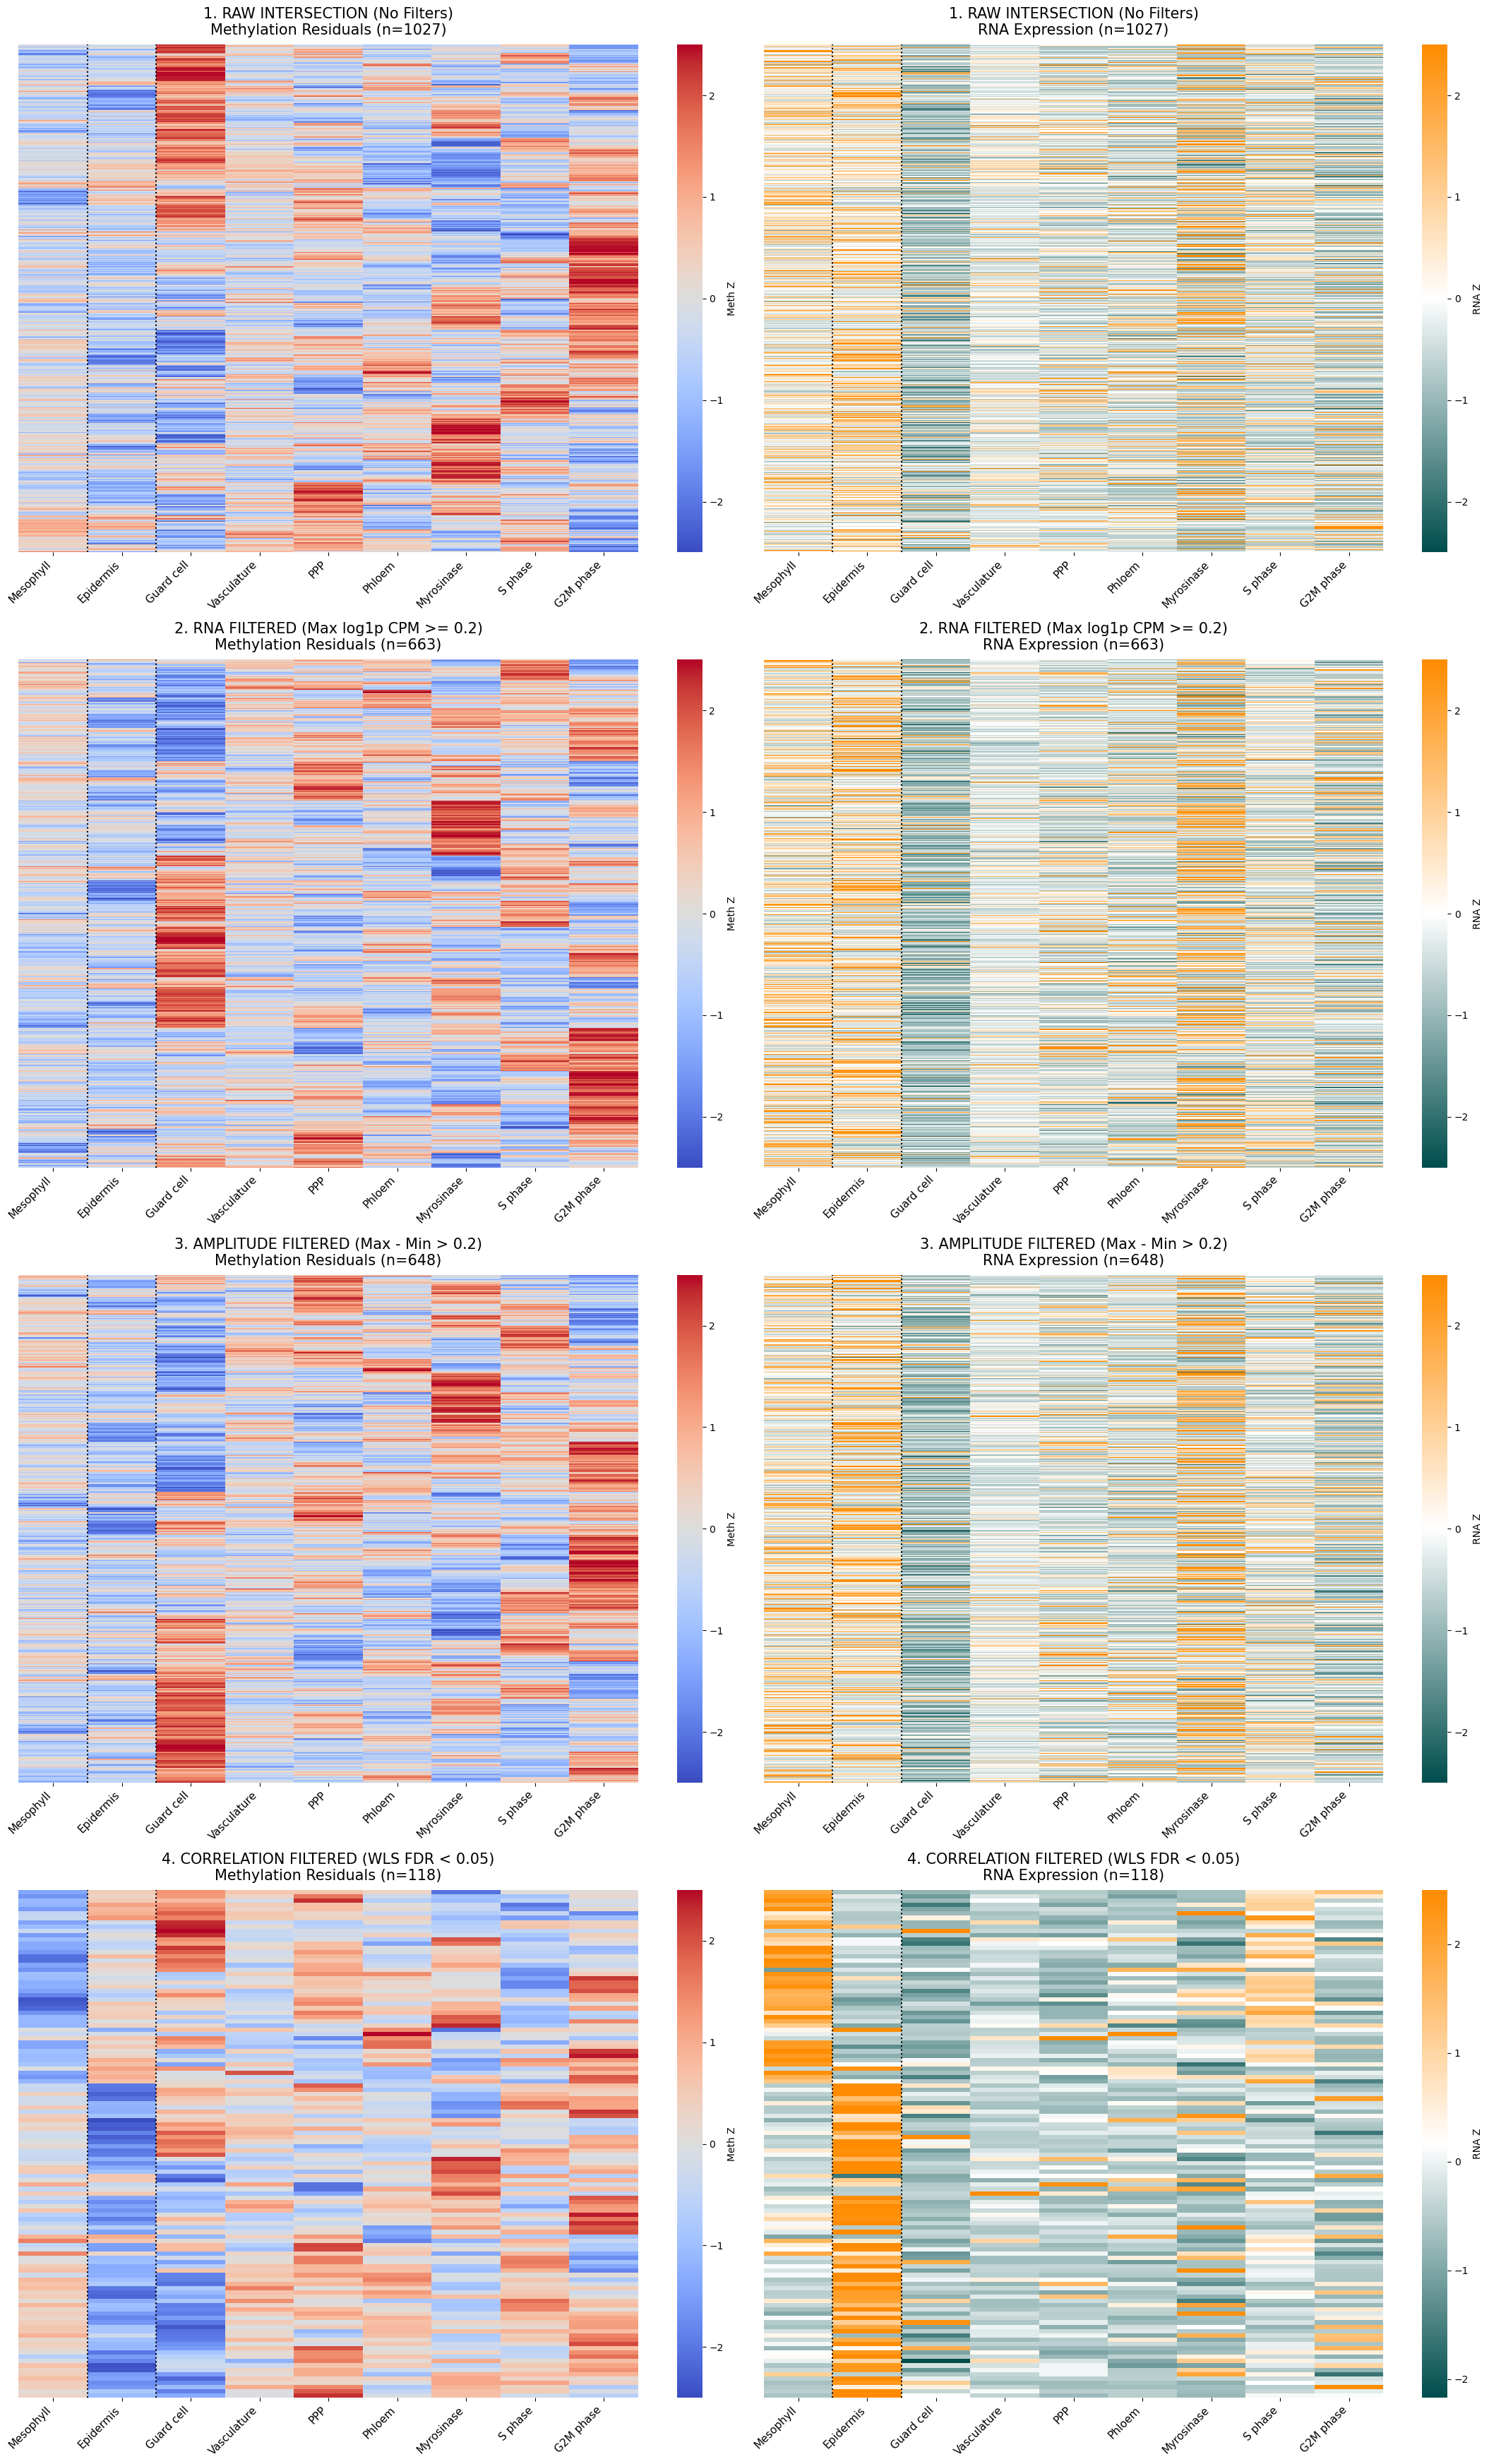

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import zscore
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import LinearSegmentedColormap
import os

# 1. Define All Clusters & Custom Colormaps
all_clusters = ['Mesophyll', 'Epidermis', 'Guard cell', 'Vasculature', 'PPP', 'Phloem', 'Myrosinase', 'S phase', 'G2M phase']

# Custom Dark Teal (#004d4d) to Rust (#FF8C00) for Methylation
teal_rust_cmap = LinearSegmentedColormap.from_list("Teal_Rust", ["#004d4d", "white", "#FF8C00"])
# Custom White to Forest Green for RNA
rna_cmap = LinearSegmentedColormap.from_list("Grey_Green", ["white", "forestgreen"])

# ==========================================
# 2. DEFINE THE SCOPES
# ==========================================

# SCOPE 1: No Filter (Raw Intersection of Hazel list with matrices)
scope_1_raw = cluster_rna_matrix.index.intersection(adj_meth_matrix.index).intersection(hazel_genes)
print(f"Scope 1 (Raw Intersection): {len(scope_1_raw)} genes")

# SCOPE 2: RNA CPM >= 0.2 Filter
rna_mask = cluster_rna_matrix.loc[scope_1_raw].max(axis=1) >= 0.2
scope_2_rna = scope_1_raw[rna_mask]
print(f"Scope 2 (RNA >= 0.2): {len(scope_2_rna)} genes")

# SCOPE 3: Amplitude Filter (Max - Min > 0.2)
rna_max = cluster_rna_matrix.loc[scope_1_raw].max(axis=1)
rna_min = cluster_rna_matrix.loc[scope_1_raw].min(axis=1)
amplitude_mask = (rna_max - rna_min) > 0.2
scope_exploratory_amp = scope_1_raw[amplitude_mask]
print(f"Scope 3 (Max - Min > 0.2): {len(scope_exploratory_amp)} genes")

# SCOPE 4: Correlation Score Filter (WLS FDR < 0.05)
valid_genes, p_vals = [], []
for gene in scope_2_rna: # Using Scope 2 as the base for stats
    r_vals = cluster_rna_matrix.loc[gene].values
    m_vals = adj_meth_matrix.loc[gene].values
    w_vals = cluster_m.loc[gene].values
    
    if np.std(r_vals) == 0 or np.std(m_vals) == 0:
        continue
        
    try:
        mod = sm.WLS(zscore(r_vals), sm.add_constant(zscore(m_vals)), weights=w_vals).fit()
        valid_genes.append(gene)
        p_vals.append(mod.pvalues[1])
    except:
        continue

stats_df = pd.DataFrame({'pval': p_vals}, index=valid_genes)
if len(stats_df) > 0:
    stats_df['fdr'] = multipletests(stats_df['pval'], method='fdr_bh')[1]
    scope_3_sig = stats_df[stats_df['fdr'] < 0.05].index
else:
    scope_3_sig = pd.Index([])
print(f"Scope 4 (FDR < 0.05): {len(scope_3_sig)} genes")

# ==========================================
# 3. HELPER FUNCTION FOR PLOTTING
# ==========================================
def get_clustered_data(genes):
    z_meth = adj_meth_matrix.loc[genes, all_clusters].apply(zscore, axis=1).clip(-2.5, 2.5)
    z_rna = cluster_rna_matrix.loc[genes, all_clusters].apply(zscore, axis=1).clip(-2.5, 2.5)
    
    z_meth = z_meth.fillna(0)
    z_rna = z_rna.fillna(0)
    
    if len(genes) > 1:
        linkage = hc.linkage(sp.distance.pdist(z_meth.values), method='ward')
        order = hc.leaves_list(linkage)
        return z_meth.iloc[order], z_rna.iloc[order]
    return z_meth, z_rna

# ==========================================
# 4. BUILD THE 4-TIER PLOT
# ==========================================
# Fixed to 4 rows and increased height from 28 to 35 so panels aren't squished
fig, axes = plt.subplots(4, 2, figsize=(22, 35)) 
scopes = [
    (scope_1_raw, "1. RAW INTERSECTION (No Filters)"),
    (scope_2_rna, "2. RNA FILTERED (Max log1p CPM >= 0.2)"),
    (scope_exploratory_amp, "3. AMPLITUDE FILTERED (Max - Min > 0.2)"),
    (scope_3_sig, "4. CORRELATION FILTERED (WLS FDR < 0.05)")
]

for i, (genes, title) in enumerate(scopes):
    if len(genes) == 0:
        continue
        
    m_plot, r_plot = get_clustered_data(genes)
    
    # Methylation Heatmap (Left) - Fixed to use teal_rust_cmap
    sns.heatmap(m_plot, cmap="coolwarm", center=0, ax=axes[i, 0], cbar_kws={'label': 'Meth Z'}, yticklabels=False)
    axes[i, 0].set_title(f"{title}\nMethylation Residuals (n={len(genes)})", fontsize=15, pad=10)
    
    # RNA Heatmap (Right) - Fixed to use rna_cmap
    sns.heatmap(r_plot, cmap=teal_rust_cmap, ax=axes[i, 1], cbar_kws={'label': 'RNA Z'}, yticklabels=False)
    axes[i, 1].set_title(f"{title}\nRNA Expression (n={len(genes)})", fontsize=15, pad=10)

# Global Formatting
for ax in axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
    
    # Add vertical dividers
    ax.axvline(1, color='black', lw=1.5, linestyle=':') 
    ax.axvline(2, color='black', lw=1.5, linestyle=':')

plt.tight_layout()
plt.tight_layout()

# ==========================================
# 5. SAVE THE STITCHED FIGURE
# ==========================================
# Define the directory and file name
save_dir = './figures/heatmaps/'
file_name = '4_tier_scope_comparison.png' # You can also change this to .pdf

# Create the directory if it doesn't exist yet to prevent errors
os.makedirs(save_dir, exist_ok=True)

# Save the figure with high resolution (dpi=300 prevents blurriness)
full_path = os.path.join(save_dir, file_name)
plt.savefig(full_path, dpi=300, bbox_inches='tight', facecolor='white')

print(f"✅ Stitched heatmap successfully saved to: {full_path}")

# Optional: You can still display it in the notebook after saving
plt.show()

In [28]:
scope_1_raw

Index(['AT1G01300', 'AT1G01770', 'AT1G01780', 'AT1G01830', 'AT1G01950',
       'AT1G02110', 'AT1G02500', 'AT1G03040', 'AT1G03140', 'AT1G03290',
       ...
       'AT5G63020', 'AT5G63550', 'AT5G64740', 'AT5G65280', 'AT5G66050',
       'AT5G66520', 'AT5G66600', 'AT5G67340', 'AT5G67385', 'AT5G67440'],
      dtype='object', length=1027)

In [29]:
adj_meth_matrix

cluster,Epidermis,G2M phase,Guard cell,Mesophyll,Myrosinase,PPP,Phloem,S phase,Vasculature
gene,,,,,,,,,
AT1G01010,2.620699e-03,0.014588,0.000556,-0.001369,-7.439732e-03,-0.011259,2.857096e-03,6.303132e-03,0.001030
AT1G01020,-1.328597e-03,-0.034810,-0.000414,0.003276,3.148146e-02,0.005148,-3.743549e-02,-4.090334e-03,-0.011655
AT1G03987,-1.750117e-04,0.110977,-0.014732,-0.003930,-1.174591e-02,-0.013390,1.918285e-02,8.755463e-02,-0.001610
AT1G01030,4.235380e-04,-0.007454,-0.005591,0.000258,1.973683e-03,-0.004667,-5.261701e-04,3.137662e-04,-0.001484
AT1G01040,-1.585649e-02,0.011052,0.060093,0.001921,2.025597e-02,-0.014109,-2.942385e-02,-1.311276e-02,0.040854
...,...,...,...,...,...,...,...,...,...
ATCG01270,-9.867119e-07,-0.000001,-0.000001,-0.000001,-9.211272e-07,-0.000001,-8.715052e-07,-9.766710e-07,-0.000001
ATCG01280,1.623725e-02,-0.016960,-0.017814,-0.001092,-1.421273e-02,-0.016196,-1.345738e-02,-1.505685e-02,-0.016347
ATCG01290,-9.867119e-07,-0.000001,-0.000001,-0.000001,-9.211272e-07,-0.000001,-8.715052e-07,-9.766710e-07,-0.000001


In [30]:
cluster_rna_matrix

cluster,Epidermis,G2M phase,Guard cell,Mesophyll,Myrosinase,PPP,Phloem,S phase,Vasculature
AT1G01010,0.037457,0.123274,0.016309,0.075670,0.103218,0.000000,0.020117,0.178207,0.048096
AT1G01020,0.743411,0.481391,0.221479,0.982423,0.903148,0.203666,0.584201,0.682061,0.576624
AT1G01030,0.154466,0.370302,0.057338,0.247133,0.032590,0.138163,0.165419,0.323830,0.143114
AT1G01040,0.915504,0.920084,0.631241,1.146338,1.413787,1.777067,1.577694,0.619029,1.098356
AT1G01046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
ATMG01370,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01375,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01380,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01390,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [38]:
# 1. Find Hazel genes that exist in the observed methylation matrix
hazel_in_meth = hazel_genes.intersection(obs_p.index)

# 2. Check if the max methylation fraction across the 9 clusters is >= 0.1
meth_mask = (obs_p.loc[hazel_in_meth] >= 0.1).any(axis=1)

# 3. Filter the list
hazel_highly_meth = hazel_in_meth[meth_mask]

print(f"Total Hazel genes present in methylation data: {len(hazel_in_meth)}")
print(f"Hazel genes passing the >= 0.1 methylation filter: {len(hazel_highly_meth)}")

Total Hazel genes present in methylation data: 1027
Hazel genes passing the >= 0.1 methylation filter: 852


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import zscore
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import LinearSegmentedColormap

# 1. Define Uncollapsed Clusters & Custom Colormaps
cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', 
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]

teal_rust_cmap = LinearSegmentedColormap.from_list("Teal_Rust", ["#004d4d", "white", "#FF8C00"])
rna_cmap = LinearSegmentedColormap.from_list("Grey_Green", ["white", "forestgreen"])

# ==========================================
# 2. DEFINE THE SCOPES (Using Uncollapsed Matrices)
# ==========================================
# ASSUMPTION: You have matrices named uncollapsed_rna_matrix, uncollapsed_adj_meth_matrix, uncollapsed_cluster_m
rna_df = uncollapsed_rna_matrix
meth_df = uncollapsed_adj_meth_matrix
weights_df = uncollapsed_cluster_m

# SCOPE 1: No Filter
scope_1_raw = rna_df.index.intersection(meth_df.index).intersection(hazel_genes)
print(f"Scope 1 (Raw Intersection): {len(scope_1_raw)} genes")

# SCOPE 2: RNA CPM >= 0.2 Filter
rna_mask = rna_df.loc[scope_1_raw].max(axis=1) >= 0.2
scope_2_rna = scope_1_raw[rna_mask]
print(f"Scope 2 (RNA >= 0.2): {len(scope_2_rna)} genes")

# SCOPE 3: Amplitude Filter (Max - Min > 0.2)
rna_max = rna_df.loc[scope_1_raw].max(axis=1)
rna_min = rna_df.loc[scope_1_raw].min(axis=1)
amplitude_mask = (rna_max - rna_min) > 0.2
scope_exploratory_amp = scope_1_raw[amplitude_mask]
print(f"Scope 3 (Max - Min > 0.2): {len(scope_exploratory_amp)} genes")

# SCOPE 4: Correlation Score Filter (WLS FDR < 0.05)
valid_genes, p_vals = [], []
for gene in scope_2_rna:
    r_vals = rna_df.loc[gene, cluster_order].values
    m_vals = meth_df.loc[gene, cluster_order].values
    w_vals = weights_df.loc[gene, cluster_order].values
    
    if np.std(r_vals) == 0 or np.std(m_vals) == 0:
        continue
        
    try:
        mod = sm.WLS(zscore(r_vals), sm.add_constant(zscore(m_vals)), weights=w_vals).fit()
        valid_genes.append(gene)
        p_vals.append(mod.pvalues[1])
    except:
        continue

stats_df = pd.DataFrame({'pval': p_vals}, index=valid_genes)
if len(stats_df) > 0:
    stats_df['fdr'] = multipletests(stats_df['pval'], method='fdr_bh')[1]
    scope_3_sig = stats_df[stats_df['fdr'] < 0.05].index
else:
    scope_3_sig = pd.Index([])
print(f"Scope 4 (FDR < 0.05): {len(scope_3_sig)} genes")

# ==========================================
# 3. HELPER FUNCTION FOR PLOTTING
# ==========================================
def get_clustered_data(genes):
    z_meth = meth_df.loc[genes, cluster_order].apply(zscore, axis=1).clip(-2.5, 2.5).fillna(0)
    z_rna = rna_df.loc[genes, cluster_order].apply(zscore, axis=1).clip(-2.5, 2.5).fillna(0)
    
    if len(genes) > 1:
        linkage = hc.linkage(sp.distance.pdist(z_meth.values), method='ward')
        order = hc.leaves_list(linkage)
        return z_meth.iloc[order], z_rna.iloc[order]
    return z_meth, z_rna

# ==========================================
# 4. BUILD THE 4-TIER PLOT
# ==========================================
fig, axes = plt.subplots(4, 2, figsize=(22, 35)) 
scopes = [
    (scope_1_raw, "1. RAW INTERSECTION (No Filters)"),
    (scope_2_rna, "2. RNA FILTERED (Max log1p CPM >= 0.2)"),
    (scope_exploratory_amp, "3. AMPLITUDE FILTERED (Max - Min > 0.2)"),
    (scope_3_sig, "4. CORRELATION FILTERED (WLS FDR < 0.05)")
]

for i, (genes, title) in enumerate(scopes):
    if len(genes) == 0:
        continue
        
    m_plot, r_plot = get_clustered_data(genes)
    
    # Methylation Heatmap (Left)
    sns.heatmap(m_plot, cmap=teal_rust_cmap, center=0, ax=axes[i, 0], cbar_kws={'label': 'Meth Z'}, yticklabels=False)
    axes[i, 0].set_title(f"{title}\nMethylation Residuals (n={len(genes)})", fontsize=15, pad=10)
    
    # RNA Heatmap (Right)
    sns.heatmap(r_plot, cmap=rna_cmap, ax=axes[i, 1], cbar_kws={'label': 'RNA Z'}, yticklabels=False)
    axes[i, 1].set_title(f"{title}\nRNA Expression (n={len(genes)})", fontsize=15, pad=10)

# Global Formatting
for ax in axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
    
    # Updated vertical dividers for the uncollapsed layout
    ax.axvline(5, color='black', lw=2, linestyle=':')  # After the 5 Mesophyll stages
    ax.axvline(10, color='black', lw=2, linestyle=':') # After the 5 Epidermis stages

plt.tight_layout()
plt.show()

NameError: name 'uncollapsed_rna_matrix' is not defined